In [1]:
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

DATASET_DIR = Path(r"D:\Workspace\Repository\thesis\research\object-detection-engine\data\plantdoc")
IMAGES_DIR = DATASET_DIR / "train" / "images"
LABELS_DIR = DATASET_DIR / "train" / "labels"

CLASS_NAMES = [
    'Apple Scab Leaf', 'Apple leaf', 'Apple rust leaf', 'Bell_pepper leaf',
    'Bell_pepper leaf spot', 'Blueberry leaf', 'Cherry leaf', 'Corn Gray leaf spot',
    'Corn leaf blight', 'Corn rust leaf', 'Peach leaf', 'Potato leaf',
    'Potato leaf early blight', 'Potato leaf late blight', 'Raspberry leaf',
    'Soyabean leaf', 'Soybean leaf', 'Squash Powdery mildew leaf', 'Strawberry leaf',
    'Tomato Early blight leaf', 'Tomato Septoria leaf spot', 'Tomato leaf',
    'Tomato leaf bacterial spot', 'Tomato leaf late blight', 'Tomato leaf mosaic virus',
    'Tomato leaf yellow virus', 'Tomato mold leaf', 'Tomato two spotted spider mites leaf',
    'grape leaf', 'grape leaf black rot'
]

HEALTHY_IDS = {1, 3, 5, 6, 10, 11, 14, 15, 16, 18, 21, 28}
DISEASE_IDS = set(range(30)) - HEALTHY_IDS


In [2]:
def parse_labels(label_path):
    boxes = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                cls = int(parts[0])
                cx, cy, w, h = map(float, parts[1:5])
                boxes.append((cls, cx, cy, w, h))
    return boxes


def get_primary_class(label_path):
    boxes = parse_labels(label_path)
    if not boxes:
        return None
    return boxes[0][0]


def sample_images(n_disease=3, n_healthy=2, seed=42):
    random.seed(seed)
    label_files = list(LABELS_DIR.glob("*.txt"))

    disease_pool, healthy_pool = [], []
    for lf in label_files:
        cls = get_primary_class(lf)
        if cls is None:
            continue
        img_path = IMAGES_DIR / (lf.stem + ".jpg")
        if not img_path.exists():
            continue
        if cls in DISEASE_IDS:
            disease_pool.append((img_path, lf, cls))
        elif cls in HEALTHY_IDS:
            healthy_pool.append((img_path, lf, cls))

    sampled_disease = random.sample(disease_pool, n_disease)
    sampled_healthy = random.sample(healthy_pool, n_healthy)
    return sampled_disease + sampled_healthy


samples = sample_images(seed=1)
print("Sampled classes:", [CLASS_NAMES[cls] for _, _, cls in samples])


Sampled classes: ['Apple rust leaf', 'Potato leaf early blight', 'Potato leaf late blight', 'Soyabean leaf', 'Apple leaf']


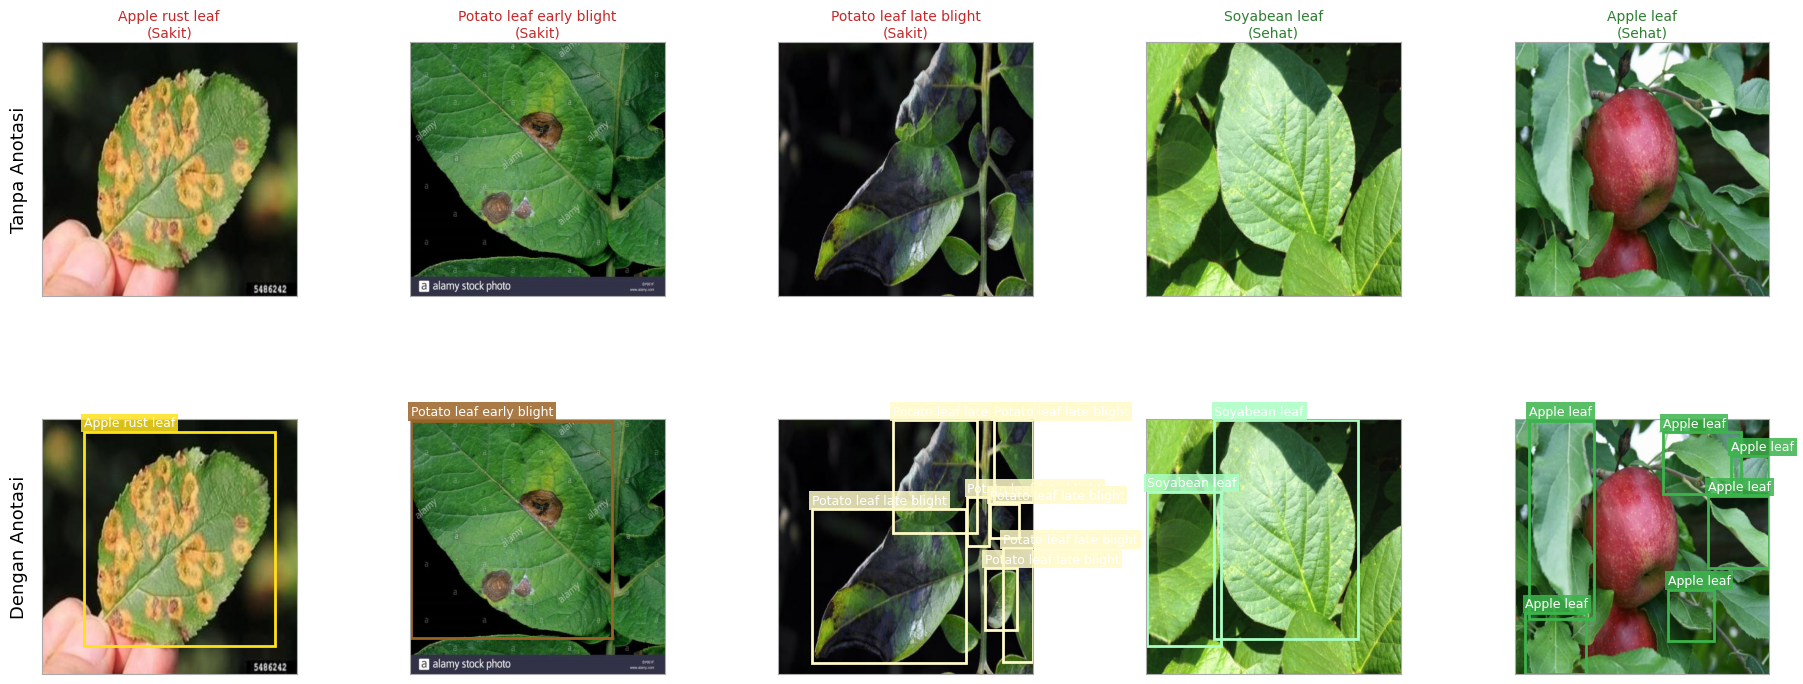

In [3]:
COLORS = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231",
    "#911eb4", "#46f0f0", "#f032e6", "#bcf60c", "#fabebe",
    "#008080", "#e6beff", "#9a6324", "#fffac8", "#800000",
    "#aaffc3", "#808000", "#ffd8b1", "#000075", "#808080",
    "#ffffff", "#000000", "#e6194b", "#3cb44b", "#ffe119",
    "#4363d8", "#f58231", "#911eb4", "#46f0f0", "#f032e6",
]


def draw_boxes(ax, img, boxes):
    w, h = img.size
    for cls, cx, cy, bw, bh in boxes:
        x = (cx - bw / 2) * w
        y = (cy - bh / 2) * h
        box_w = bw * w
        box_h = bh * h
        color = COLORS[cls % len(COLORS)]
        rect = patches.FancyBboxPatch(
            (x, y), box_w, box_h,
            linewidth=2, edgecolor=color, facecolor="none",
            boxstyle="square,pad=0"
        )
        ax.add_patch(rect)
        ax.text(
            x, y - 4, CLASS_NAMES[cls],
            fontsize=9, color="white",
            bbox=dict(facecolor=color, alpha=0.85, pad=2, edgecolor="none"),
            verticalalignment="bottom"
        )


fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.patch.set_facecolor("white")

row_labels = ["Tanpa Anotasi", "Dengan Anotasi"]
for row_idx, label in enumerate(row_labels):
    axes[row_idx, 0].set_ylabel(label, fontsize=13, color="black", labelpad=10)

for col_idx, (img_path, lf, cls) in enumerate(samples):
    img = Image.open(img_path).convert("RGB")
    boxes = parse_labels(lf)
    is_healthy = cls in HEALTHY_IDS
    status = "Sehat" if is_healthy else "Sakit"
    title_color = "#2e7d32" if is_healthy else "#c62828"

    for row_idx in range(2):
        ax = axes[row_idx, col_idx]
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor("#aaa")

        if row_idx == 0:
            ax.set_title(f"{CLASS_NAMES[cls]}\n({status})", fontsize=10,
                         color=title_color, pad=4)
        else:
            draw_boxes(ax, img, boxes)

for ax in axes.flat:
    ax.set_facecolor("white")

plt.tight_layout(pad=0.5, h_pad=0.5, w_pad=0.5)
plt.savefig("plantdoc_samples.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
